# Balancing Volume Comparison: IV Algorithm vs Real ELEXON Accepted Volumes (2024)

This notebook compares the total daily balancing **volumes** from the explicit zonal balancing market clearing algorithm (IV extension) against the real accepted balancing volumes from ELEXON.

**Data sources:**
- **IV algorithm volumes**: `results/{day}/IV_clearing_settlement_summary_flex.csv` → sum of `cleared_volume_mwh` per day, split by direction (up/down)
- **Real ELEXON volumes**: `data/base/{day}/bids.csv` and `offers.csv` → sum of accepted `vol` rows per settlement period (bids = turndown, offers = turn-up), converted to MWh (×0.5 for half-hour)

**Coverage:** 363 days of IV results, 364 days of real ELEXON data.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

ROOT = Path(r"c:\GBPower")
RESULTS_DIR = ROOT / "results"
DATA_DIR = ROOT / "data" / "base"

all_dates = sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.startswith("2024")])
print(f"Found {len(all_dates)} result date folders (2024)")
print(f"Date range: {all_dates[0]} to {all_dates[-1]}")

Found 366 result date folders (2024)
Date range: 2024-01-01 to 2024-12-31


## Load and Aggregate Daily Balancing Volumes

For each day:
- **IV algorithm**: from `IV_clearing_settlement_summary_flex.csv`, sum `cleared_volume_mwh` separately for `direction='up'` and `direction='down'`
- **Real ELEXON**: from `bids.csv` (turndown volumes) and `offers.csv` (turn-up volumes), sum all `vol` rows × 0.5 to get MWh

In [11]:
def compute_real_balancing_volume(day_str):
    """
    Compute real accepted balancing volumes from ELEXON bids/offers.
    
    bids.csv/offers.csv: wide format, alternating vol/price rows.
    Volume in MW per half-hour → multiply by 0.5 to get MWh.
    
    Returns dict with offer_vol_mwh (turn-up), bid_vol_mwh (turndown), total_vol_mwh.
    """
    base_path = DATA_DIR / day_str
    result = {'offer_vol_mwh': np.nan, 'bid_vol_mwh': np.nan, 'total_vol_mwh': np.nan}
    
    for file_type in ['offers', 'bids']:
        fpath = base_path / f"{file_type}.csv"
        if not fpath.exists():
            continue
        
        df = pd.read_csv(fpath, index_col=[0, 1])
        vols = df.loc[pd.IndexSlice[:, 'vol'], :]
        # Each vol entry is MW for a half-hour period → MWh = MW × 0.5
        total_mwh = vols.sum().sum() * 0.5
        
        if file_type == 'offers':
            result['offer_vol_mwh'] = total_mwh
        else:
            result['bid_vol_mwh'] = total_mwh
    
    if not np.isnan(result['offer_vol_mwh']) or not np.isnan(result['bid_vol_mwh']):
        result['total_vol_mwh'] = np.nansum([result['offer_vol_mwh'], result['bid_vol_mwh']])
    
    return result


def compute_iv_algorithm_volume(day_str):
    """
    Compute IV algorithm cleared volumes from settlement summary.
    Returns dict with up_vol_mwh, down_vol_mwh, total_vol_mwh.
    """
    fpath = RESULTS_DIR / day_str / "IV_clearing_settlement_summary_flex.csv"
    if not fpath.exists():
        return {'up_vol_mwh': np.nan, 'down_vol_mwh': np.nan, 'total_vol_mwh': np.nan}
    
    df = pd.read_csv(fpath)
    up = df.loc[df['direction'] == 'up', 'cleared_volume_mwh'].sum() * 0.5   # MW per SP → MWh
    down = df.loc[df['direction'] == 'down', 'cleared_volume_mwh'].sum() * 0.5
    
    return {'up_vol_mwh': up, 'down_vol_mwh': down, 'total_vol_mwh': up + down}


# Collect all days
rows = []
missing_iv = []
missing_real = []

for day in tqdm(all_dates, desc="Loading daily volumes"):
    iv = compute_iv_algorithm_volume(day)
    real = compute_real_balancing_volume(day)
    
    if np.isnan(iv['total_vol_mwh']):
        missing_iv.append(day)
    if np.isnan(real['total_vol_mwh']):
        missing_real.append(day)
    
    rows.append({
        'date': pd.Timestamp(day),
        'iv_up_mwh': iv['up_vol_mwh'],
        'iv_down_mwh': iv['down_vol_mwh'],
        'iv_total_mwh': iv['total_vol_mwh'],
        'real_offer_mwh': real['offer_vol_mwh'],
        'real_bid_mwh': real['bid_vol_mwh'],
        'real_total_mwh': real['total_vol_mwh'],
    })

df_vol = pd.DataFrame(rows).set_index('date')

print(f"\nLoaded {len(df_vol)} days")
print(f"Missing IV results: {len(missing_iv)} days — {missing_iv}")
print(f"Missing real data: {len(missing_real)} days — {missing_real}")
df_vol.head()

Loading daily volumes: 100%|██████████| 366/366 [00:12<00:00, 30.12it/s]


Loaded 366 days
Missing IV results: 3 days — ['2024-09-24', '2024-09-25', '2024-09-26']
Missing real data: 3 days — ['2024-01-01', '2024-01-02', '2024-01-15']


,iv_up_mwh,iv_down_mwh,iv_total_mwh,real_offer_mwh,real_bid_mwh,real_total_mwh
date,,,,,,
2024-01-01,2331.600,2331.600,4663.20,NaN,NaN,NaN
2024-01-02,4597.125,4597.125,9194.25,NaN,NaN,NaN
2024-01-03,185.745,185.745,371.49,8427.808965,7042.24984,15470.058805
2024-01-04,4142.685,4142.685,8285.37,9293.258405,9257.00111,18550.259515
2024-01-05,0.000,0.000,0.00,6180.312210,6022.82349,12203.135700


## Compute Derived Columns

In [12]:
# Drop rows missing either source
df = df_vol.dropna(subset=['iv_total_mwh', 'real_total_mwh']).copy()
print(f"Clean dataset: {len(df)} days with both IV and real volumes")

# Convert to GWh for readability
for col in ['iv_up_mwh', 'iv_down_mwh', 'iv_total_mwh', 'real_offer_mwh', 'real_bid_mwh', 'real_total_mwh']:
    df[col.replace('mwh', 'gwh')] = df[col] / 1e3

# Rolling averages
df['iv_roll7'] = df['iv_total_gwh'].rolling(7, min_periods=1).mean()
df['real_roll7'] = df['real_total_gwh'].rolling(7, min_periods=1).mean()
df['iv_roll30'] = df['iv_total_gwh'].rolling(30, min_periods=1).mean()
df['real_roll30'] = df['real_total_gwh'].rolling(30, min_periods=1).mean()

# Cumulative
df['iv_cumsum'] = df['iv_total_gwh'].cumsum()
df['real_cumsum'] = df['real_total_gwh'].cumsum()

# Difference (positive = algorithm clears more volume)
df['diff_gwh'] = df['iv_total_gwh'] - df['real_total_gwh']
df['diff_cumsum'] = df['diff_gwh'].cumsum()

# Month
df['month'] = df.index.to_period('M')

print(f"\nAnnual totals:")
print(f"  IV Algorithm:  {df['iv_total_gwh'].sum():,.1f} GWh  (up: {df['iv_up_gwh'].sum():,.1f}, down: {df['iv_down_gwh'].sum():,.1f})")
print(f"  Real ELEXON:   {df['real_total_gwh'].sum():,.1f} GWh  (offers: {df['real_offer_gwh'].sum():,.1f}, bids: {df['real_bid_gwh'].sum():,.1f})")
print(f"  Difference:    {df['diff_gwh'].sum():,.1f} GWh")

Clean dataset: 360 days with both IV and real volumes

Annual totals:
  IV Algorithm:  9,606.0 GWh  (up: 4,803.0, down: 4,803.0)
  Real ELEXON:   13,471.4 GWh  (offers: 6,455.4, bids: 7,016.0)
  Difference:    -3,865.4 GWh


## Plot 1: Daily Balancing Volumes — Time Series

Top panel: raw daily volumes with 7-day rolling average.
Bottom panel: 30-day rolling average with shaded gap.

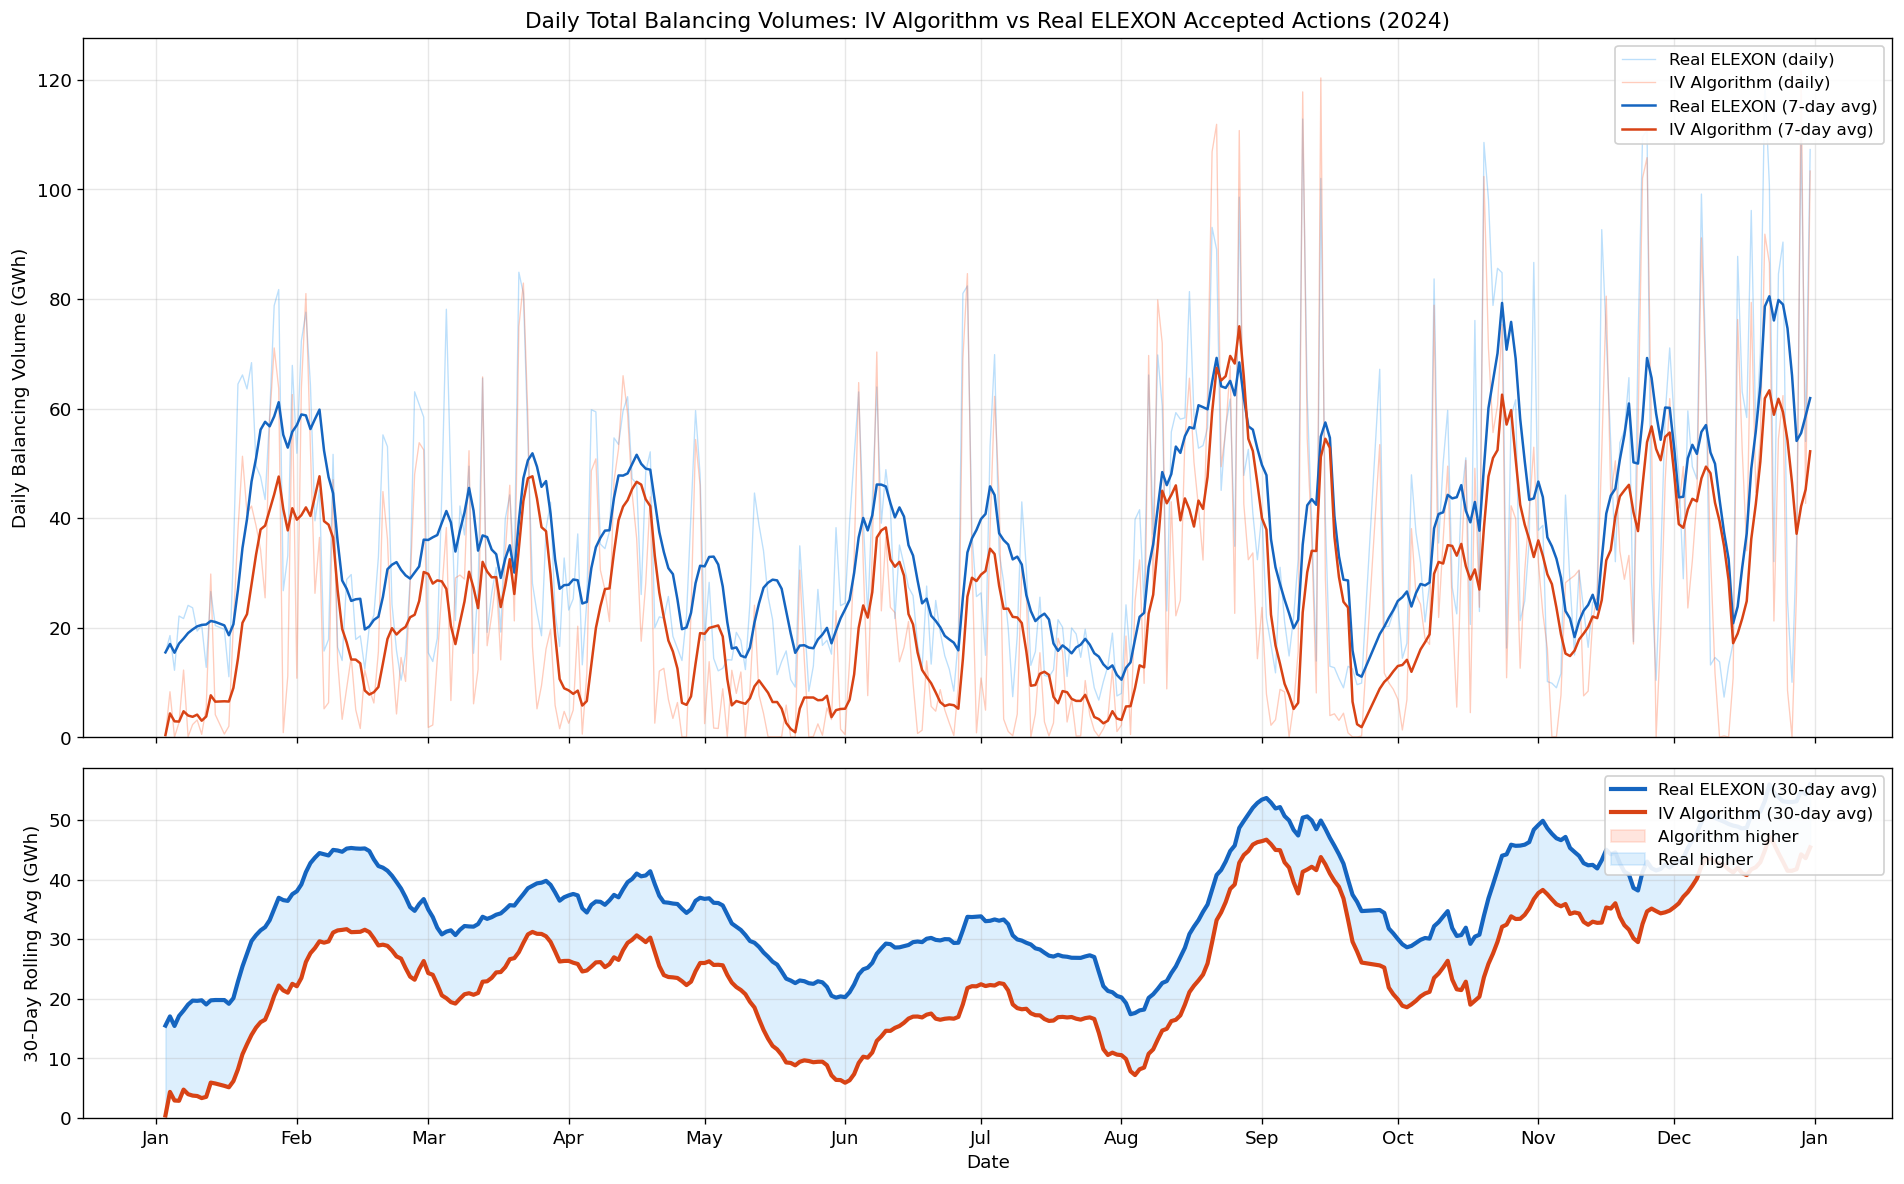

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Top: raw + 7-day rolling
ax1.plot(df.index, df['real_total_gwh'], alpha=0.3, color='#2196F3', linewidth=0.8, label='Real ELEXON (daily)')
ax1.plot(df.index, df['iv_total_gwh'], alpha=0.3, color='#FF5722', linewidth=0.8, label='IV Algorithm (daily)')
ax1.plot(df.index, df['real_roll7'], color='#1565C0', linewidth=1.5, label='Real ELEXON (7-day avg)')
ax1.plot(df.index, df['iv_roll7'], color='#D84315', linewidth=1.5, label='IV Algorithm (7-day avg)')
ax1.set_ylabel('Daily Balancing Volume (GWh)')
ax1.set_title('Daily Total Balancing Volumes: IV Algorithm vs Real ELEXON Accepted Actions (2024)')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.set_ylim(bottom=0)

# Bottom: 30-day rolling with fill
ax2.plot(df.index, df['real_roll30'], color='#1565C0', linewidth=2.5, label='Real ELEXON (30-day avg)')
ax2.plot(df.index, df['iv_roll30'], color='#D84315', linewidth=2.5, label='IV Algorithm (30-day avg)')
ax2.fill_between(df.index, df['real_roll30'], df['iv_roll30'],
                  where=df['iv_roll30'] >= df['real_roll30'],
                  alpha=0.15, color='#FF5722', label='Algorithm higher')
ax2.fill_between(df.index, df['real_roll30'], df['iv_roll30'],
                  where=df['iv_roll30'] < df['real_roll30'],
                  alpha=0.15, color='#2196F3', label='Real higher')
ax2.set_ylabel('30-Day Rolling Avg (GWh)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right', framealpha=0.9)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_daily_volume_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2: Monthly Aggregated Volume Comparison

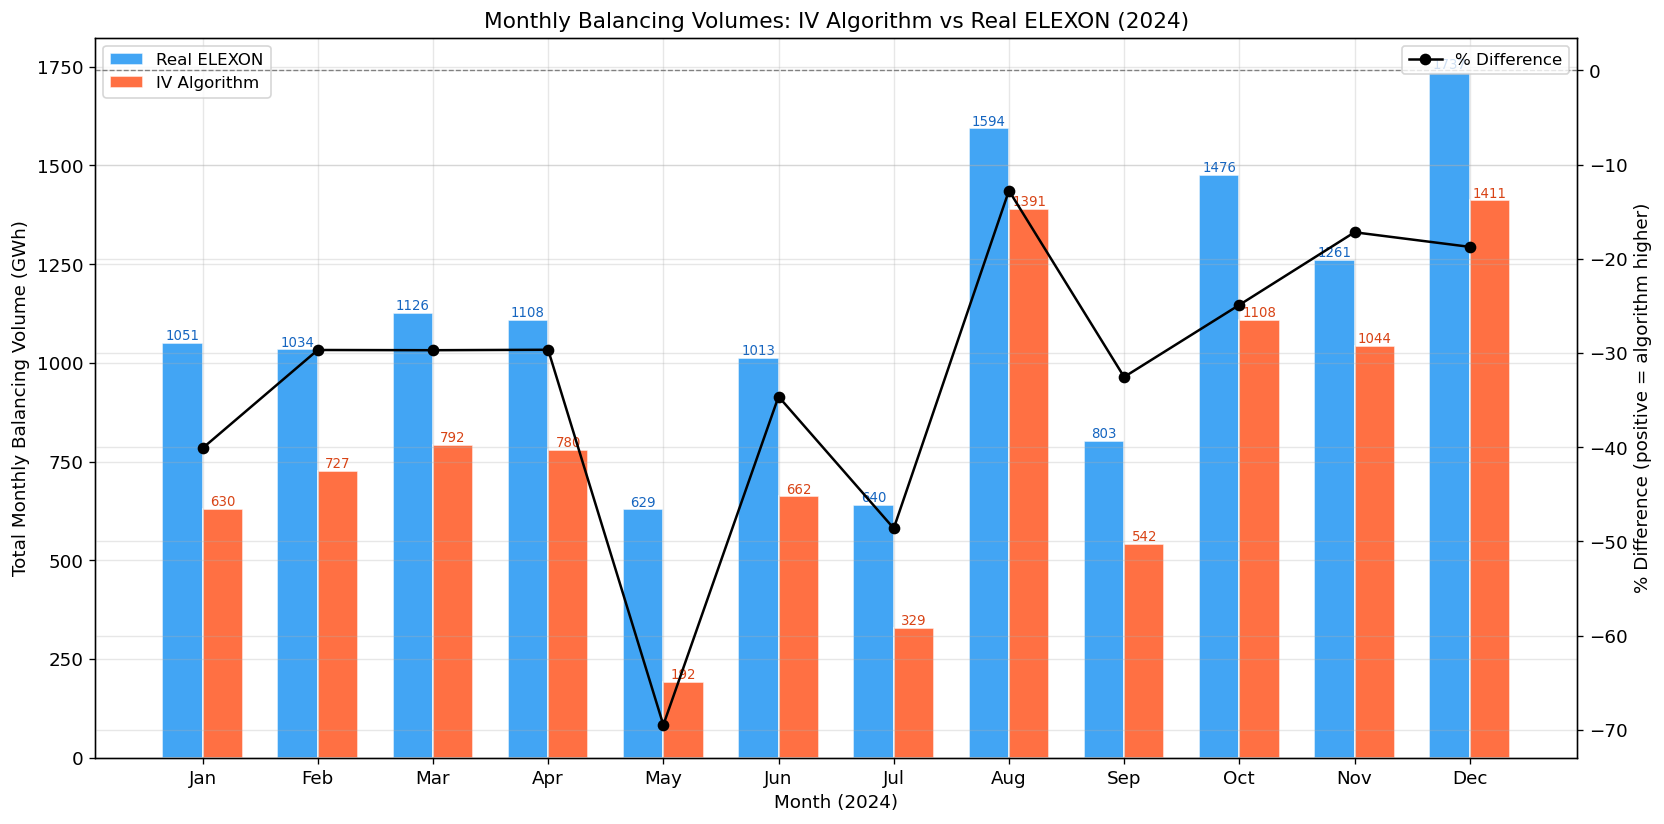


Monthly Summary:
         days  real_total  iv_total  pct_diff
month                                        
2024-01    28      1051.3     629.5     -40.1
2024-02    29      1033.9     726.9     -29.7
2024-03    31      1126.3     791.7     -29.7
2024-04    30      1108.3     779.5     -29.7
2024-05    31       628.9     191.9     -69.5
2024-06    30      1012.8     662.0     -34.6
2024-07    31       639.7     328.7     -48.6
2024-08    31      1594.3    1390.7     -12.8
2024-09    27       802.9     541.5     -32.6
2024-10    31      1475.6    1108.2     -24.9
2024-11    30      1260.6    1043.9     -17.2
2024-12    31      1737.0    1411.5     -18.7


In [14]:
monthly = df.groupby('month').agg(
    iv_total=('iv_total_gwh', 'sum'),
    real_total=('real_total_gwh', 'sum'),
    iv_up=('iv_up_gwh', 'sum'),
    iv_down=('iv_down_gwh', 'sum'),
    real_offer=('real_offer_gwh', 'sum'),
    real_bid=('real_bid_gwh', 'sum'),
    days=('iv_total_gwh', 'count'),
).copy()

monthly['pct_diff'] = (monthly['iv_total'] - monthly['real_total']) / monthly['real_total'] * 100

month_labels = [p.strftime('%b') for p in monthly.index]
x = np.arange(len(monthly))
width = 0.35

fig, ax1 = plt.subplots(figsize=(14, 7))

bars_real = ax1.bar(x - width/2, monthly['real_total'], width,
                     label='Real ELEXON', color='#2196F3', alpha=0.85, edgecolor='white')
bars_iv = ax1.bar(x + width/2, monthly['iv_total'], width,
                   label='IV Algorithm', color='#FF5722', alpha=0.85, edgecolor='white')

for bar in bars_real:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.3, f'{h:.0f}', ha='center', va='bottom', fontsize=8, color='#1565C0')
for bar in bars_iv:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.3, f'{h:.0f}', ha='center', va='bottom', fontsize=8, color='#D84315')

ax1.set_xlabel('Month (2024)')
ax1.set_ylabel('Total Monthly Balancing Volume (GWh)')
ax1.set_title('Monthly Balancing Volumes: IV Algorithm vs Real ELEXON (2024)')
ax1.set_xticks(x)
ax1.set_xticklabels(month_labels)
ax1.legend(loc='upper left')
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(x, monthly['pct_diff'], 'ko-', markersize=6, linewidth=1.5, label='% Difference')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('% Difference (positive = algorithm higher)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_monthly_volume_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMonthly Summary:")
print(monthly[['days', 'real_total', 'iv_total', 'pct_diff']].to_string(float_format='{:.1f}'.format))

## Plot 3: Daily Volume Difference with Cumulative Trend

Positive bars = algorithm clears more volume than real SO. Negative = algorithm clears less.

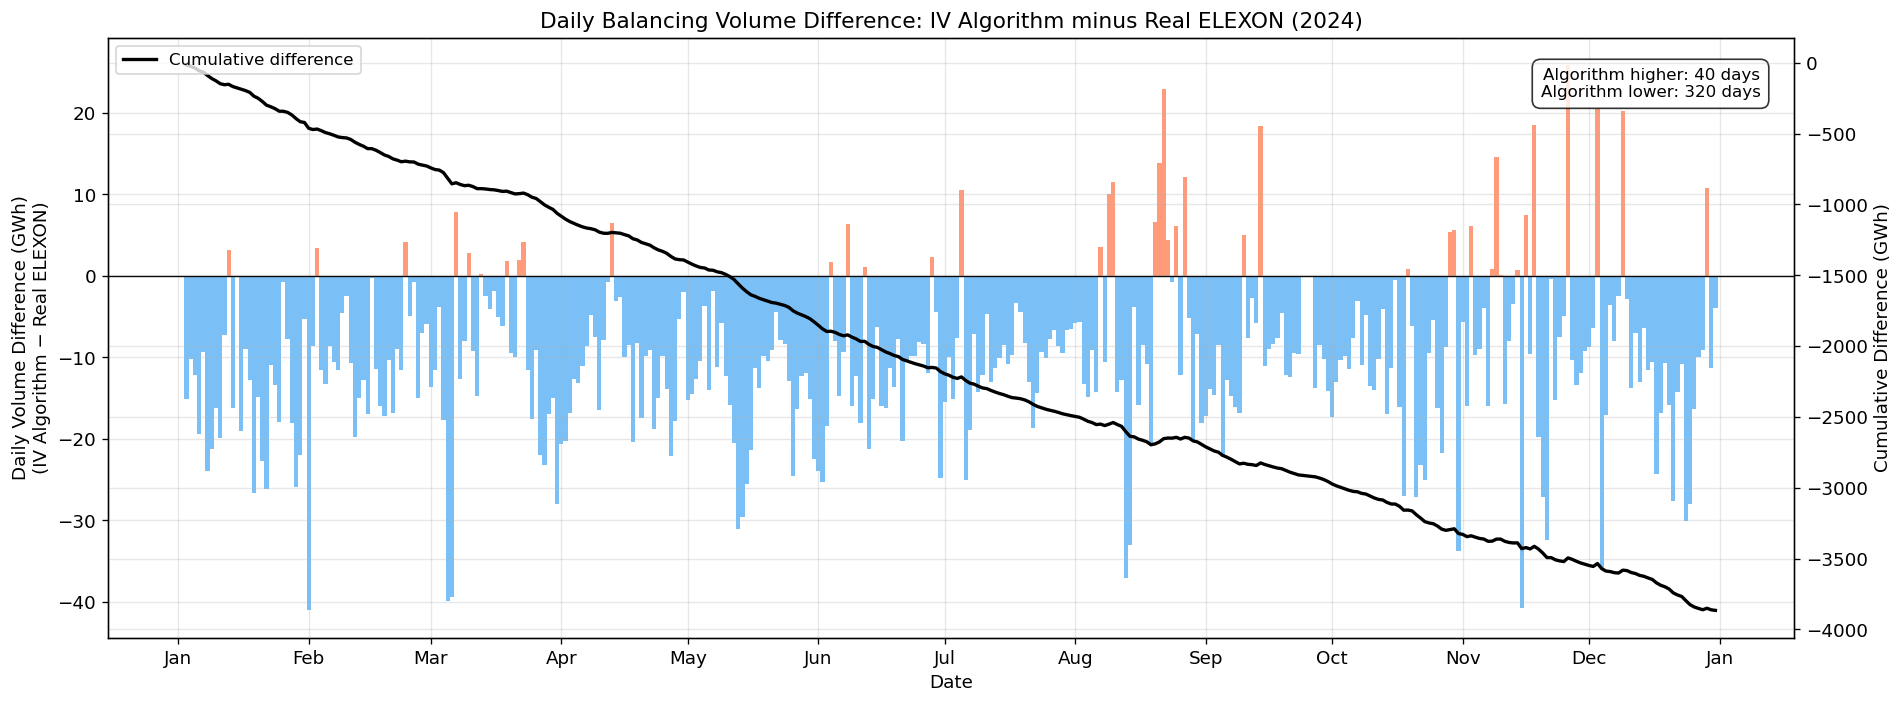

In [15]:
fig, ax1 = plt.subplots(figsize=(16, 6))

colors = ['#FF5722' if d >= 0 else '#2196F3' for d in df['diff_gwh']]
ax1.bar(df.index, df['diff_gwh'], color=colors, alpha=0.6, width=1.0, edgecolor='none')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_ylabel('Daily Volume Difference (GWh)\n(IV Algorithm − Real ELEXON)')
ax1.set_title('Daily Balancing Volume Difference: IV Algorithm minus Real ELEXON (2024)')

ax2 = ax1.twinx()
ax2.plot(df.index, df['diff_cumsum'], color='black', linewidth=2, label='Cumulative difference')
ax2.set_ylabel('Cumulative Difference (GWh)')
ax2.legend(loc='upper left')

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.set_xlabel('Date')

n_higher = (df['diff_gwh'] > 0).sum()
n_lower = (df['diff_gwh'] < 0).sum()
ax1.text(0.98, 0.95, f'Algorithm higher: {n_higher} days\nAlgorithm lower: {n_lower} days',
         transform=ax1.transAxes, ha='right', va='top', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_daily_volume_difference.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4: Scatter — IV Algorithm Volume vs Real ELEXON Volume

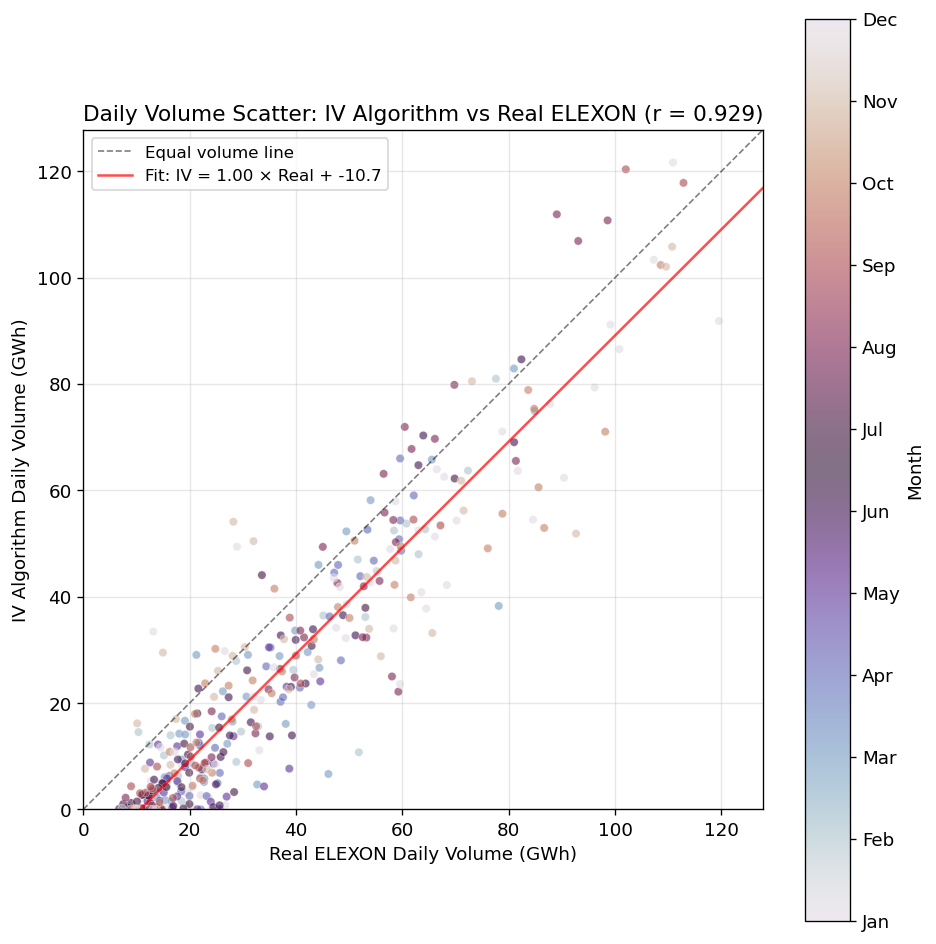

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))

month_num = df.index.month
scatter = ax.scatter(df['real_total_gwh'], df['iv_total_gwh'],
                      c=month_num, cmap='twilight', alpha=0.6, s=25, edgecolors='white', linewidth=0.3)

max_val = max(df['real_total_gwh'].max(), df['iv_total_gwh'].max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.5, label='Equal volume line')

# Regression
mask = ~(df['real_total_gwh'].isna() | df['iv_total_gwh'].isna())
coeffs = np.polyfit(df.loc[mask, 'real_total_gwh'], df.loc[mask, 'iv_total_gwh'], 1)
x_fit = np.linspace(0, max_val, 100)
ax.plot(x_fit, np.polyval(coeffs, x_fit), 'r-', linewidth=1.5, alpha=0.7,
        label=f'Fit: IV = {coeffs[0]:.2f} × Real + {coeffs[1]:.1f}')

corr = df['real_total_gwh'].corr(df['iv_total_gwh'])

ax.set_xlabel('Real ELEXON Daily Volume (GWh)')
ax.set_ylabel('IV Algorithm Daily Volume (GWh)')
ax.set_title(f'Daily Volume Scatter: IV Algorithm vs Real ELEXON (r = {corr:.3f})')
ax.legend(loc='upper left')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect('equal')

cbar = plt.colorbar(scatter, ax=ax, label='Month', ticks=range(1, 13))
cbar.ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_volume_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 5: Up vs Down Volume Breakdown — Algorithm vs Real

Compares the directional split: offers (turn-up) vs bids (turndown) for both approaches.

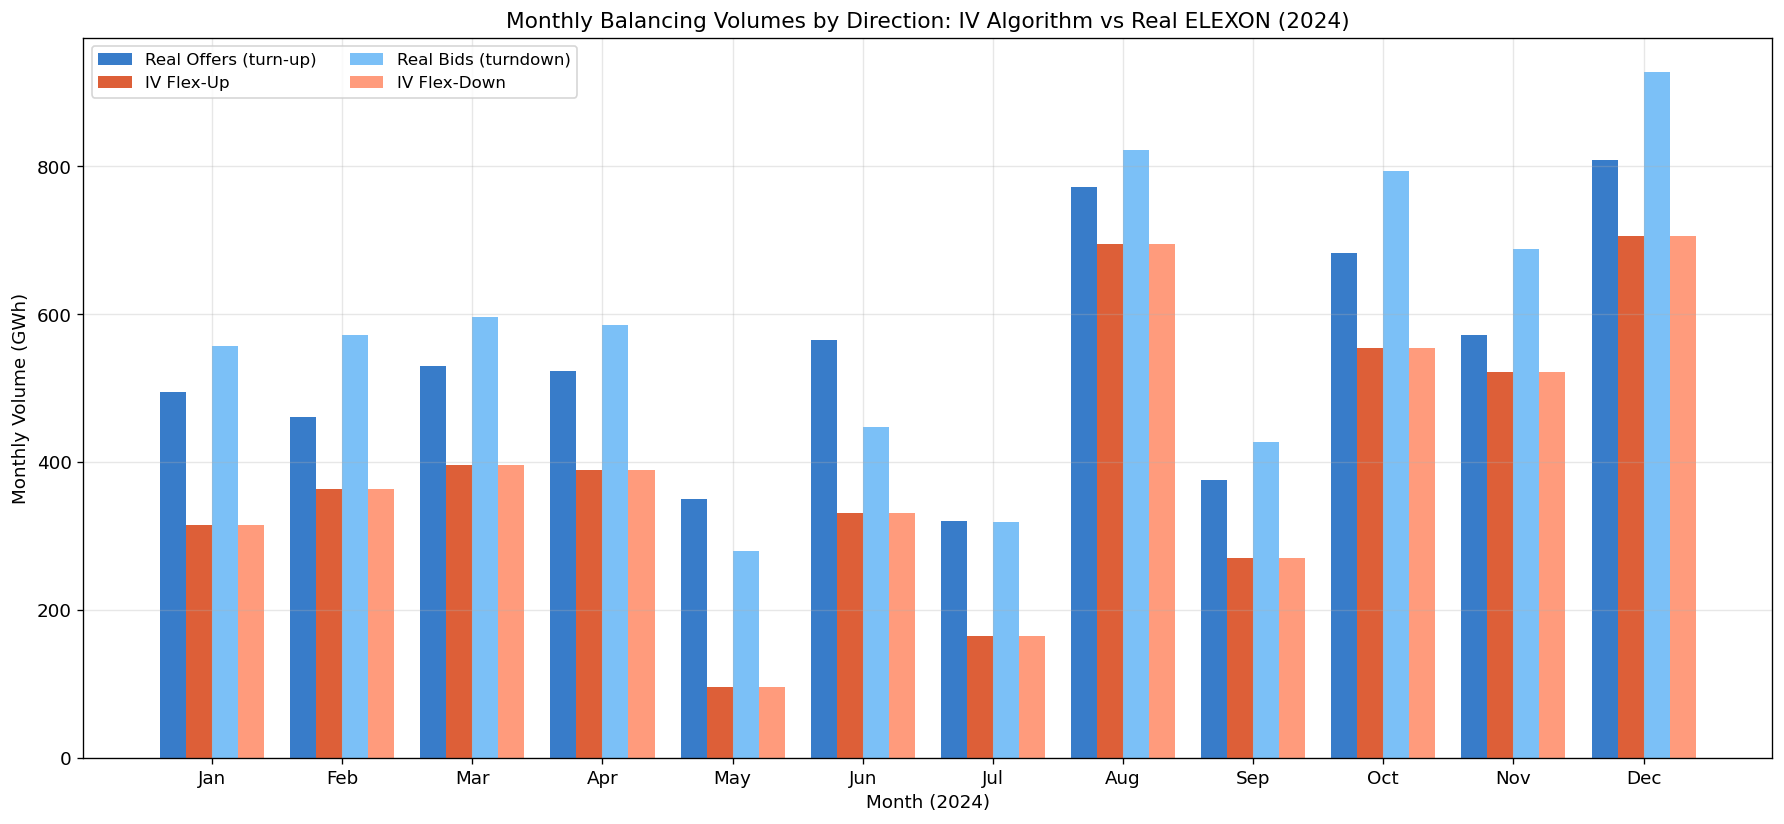

In [17]:
monthly_dir = df.groupby('month').agg(
    iv_up=('iv_up_gwh', 'sum'),
    iv_down=('iv_down_gwh', 'sum'),
    real_offer=('real_offer_gwh', 'sum'),
    real_bid=('real_bid_gwh', 'sum'),
)

x = np.arange(len(monthly_dir))
width = 0.2
month_labels = [p.strftime('%b') for p in monthly_dir.index]

fig, ax = plt.subplots(figsize=(15, 7))

ax.bar(x - 1.5*width, monthly_dir['real_offer'], width, label='Real Offers (turn-up)', color='#1565C0', alpha=0.85)
ax.bar(x - 0.5*width, monthly_dir['iv_up'], width, label='IV Flex-Up', color='#D84315', alpha=0.85)
ax.bar(x + 0.5*width, monthly_dir['real_bid'], width, label='Real Bids (turndown)', color='#64B5F6', alpha=0.85)
ax.bar(x + 1.5*width, monthly_dir['iv_down'], width, label='IV Flex-Down', color='#FF8A65', alpha=0.85)

ax.set_xlabel('Month (2024)')
ax.set_ylabel('Monthly Volume (GWh)')
ax.set_title('Monthly Balancing Volumes by Direction: IV Algorithm vs Real ELEXON (2024)')
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.legend(loc='upper left', ncol=2)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_monthly_volume_direction.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics

In [18]:
stats = {
    'Total IV Algorithm Volume (GWh)': df['iv_total_gwh'].sum(),
    '  — Flex-Up (GWh)': df['iv_up_gwh'].sum(),
    '  — Flex-Down (GWh)': df['iv_down_gwh'].sum(),
    'Total Real ELEXON Volume (GWh)': df['real_total_gwh'].sum(),
    '  — Offers / turn-up (GWh)': df['real_offer_gwh'].sum(),
    '  — Bids / turndown (GWh)': df['real_bid_gwh'].sum(),
    'Total Difference (GWh)': df['diff_gwh'].sum(),
    'Mean Daily IV Volume (GWh)': df['iv_total_gwh'].mean(),
    'Mean Daily Real Volume (GWh)': df['real_total_gwh'].mean(),
    '% Difference (annual)': (df['iv_total_gwh'].sum() - df['real_total_gwh'].sum()) / df['real_total_gwh'].sum() * 100,
    'Days Algorithm Higher': int((df['diff_gwh'] > 0).sum()),
    'Days Algorithm Lower': int((df['diff_gwh'] < 0).sum()),
    'Max Daily Excess (GWh)': df['diff_gwh'].max(),
    'Max Daily Shortfall (GWh)': df['diff_gwh'].min(),
    'Pearson Correlation': df['real_total_gwh'].corr(df['iv_total_gwh']),
    'Days Analysed': len(df),
}

summary_df = pd.DataFrame.from_dict(stats, orient='index', columns=['Value'])
summary_df['Value'] = summary_df['Value'].apply(lambda x: f'{x:,.2f}' if isinstance(x, float) else str(x))
print(summary_df.to_string())

                                     Value
Total IV Algorithm Volume (GWh)   9,605.99
  — Flex-Up (GWh)                 4,803.00
  — Flex-Down (GWh)               4,803.00
Total Real ELEXON Volume (GWh)   13,471.39
  — Offers / turn-up (GWh)        6,455.36
  — Bids / turndown (GWh)         7,016.04
Total Difference (GWh)           -3,865.40
Mean Daily IV Volume (GWh)           26.68
Mean Daily Real Volume (GWh)         37.42
% Difference (annual)               -28.69
Days Algorithm Higher                40.00
Days Algorithm Lower                320.00
Max Daily Excess (GWh)               25.87
Max Daily Shortfall (GWh)           -41.07
Pearson Correlation                   0.93
Days Analysed                       360.00
